#### Plotting $r=\pi/2$ data for supercritical case
divs = 250

In [1]:
using Plots
using JLD2
sup_shape = jldopen("sup_shape_pi_0608.jld2")
include(relpath("general_shape_opti/extend_domain.jl","shape-in-wdp"))

domain_extend (generic function with 1 method)

#### circle data 

In [92]:
# extend the waves 
# need to rerun because the code does not output the u matrices so it cannot be
# done with this. Could probably calculate u from h if I wanted to do that instead.
l = pi

π = 3.1415926535897...

In [3]:
#### Extended domain solutions
sup = jldopen("sup_pi_0608.jld2")
E = sup["E"];
F = sup["F"];

In [25]:
# domain was not wide enough in the simulation, so chop to just the body part 
# like the general shape and then use domain extend 
# results only depend on the pieces left anyway
end_ti = Int64((length(E[1][1,:])/4)+3)
qr0 = E[1][:,1:end_ti]
qi0 = E[2][:,1:end_ti]
hr0 = E[3][:,1:end_ti]
hi0 = E[4][:,1:end_ti]
ur0 = E[14][:,1:end_ti]
ui0 = E[15][:,1:end_ti]
v125 = domain_extend(qr0,qi0,ur0,ui0,hr0,hi0,E[8],E[9],1.25,E[6])

3167


([0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [0.0 0.0 … -4.382984212080367e-15 -4.398049967468496e-15; 0.0 0.0 … 6.409612539546388e-13 6.328751446727645e-13; … ; 0.0 0.0 … 3.4587153200034333e-14 3.233515846738509e-14; 0.0 0.0 … -3.968455341685651e-15 -4.038013930252852e-15], [0.0 0.0 … -2.2324819016488416e-15 -2.2334428672603683e-15; 0.0 0.0 … 5.998831788590446e-14 3.4667572736078765e-14; … ; 0.0 0.0 … 9.612755943293657e-15 8.207788073696524e-15; 0.0 0.0 … -2.8604081058519826e-15 -3.0051667054828587e-15], [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], Any[0.0, 0.00796, 0.01592, 0.02388, 0.03184, 0.0398, 0.04776, 0.05572, 0.06368, 0.07164  …  25.12972, 25.13768, 25.14564, 25.1536, 25.16156, 25.16952, 25.17748, 25.18544, 25.1934, 25.20136], [-39.7204, -39

In [149]:
# div=200
wid = length(v125[3][:,1])
x_leng = pi
# make a matrix to flip the axes
dom_len = Int64(round(1.75*length(v125[3][1,:])))
true_hr = zeros(wid,dom_len);
true_hi = zeros(wid,dom_len);
true_qr = zeros(wid,dom_len)
true_qi = zeros(wid,dom_len);

n = length(v125[3][1,:])
for i in 1:length(v125[3][1,:])
    true_qr[:,i] = v125[1][:,n-i+1]
    true_qi[:,i] = v125[2][:,n-i+1]
    true_hr[:,i] = v125[3][:,n-i+1]
    true_hi[:,i] = v125[4][:,n-i+1]
end
true_xvals = zeros(dom_len)
end_index = n
for i in 1:dom_len
    true_xvals[i] = -v125[7][end_index] + (i-1)*E[8] + x_leng/2
end

q_xvals = zeros(E[12])
for i in 1:E[12]
    q_xvals[i] = -x_leng/2 + (i-1)*E[8]
end

In [133]:
length(v125[7])

3167

In [6]:
r1 = pi/2
circ_x1 = -r1:0.01:r1
circ_plus1 = []
circ_minus1 = []
for i in 1:length(circ_x1)
    append!(circ_plus1, sqrt(r1^2 - circ_x1[i]^2))
    append!(circ_minus1, -sqrt(r1^2 - circ_x1[i]^2))
end


In [135]:
yvals = 4*E[6][1]:E[9]:4*E[6][251]

-39.8:0.07959999999999999:39.8

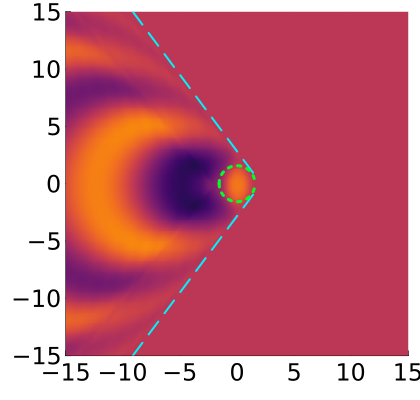

In [136]:
lhs_x = true_xvals[1]
lhs_y = yvals[1]
gamma = 1/sqrt(1.25^2-1)
x_line = lhs_x+E[8]:0.01:pi/2
y_low = zeros(length(x_line))
y_up = zeros(length(x_line))
z_line = zeros(length(x_line))
for i in 1:length(z_line)
    z_line[i] -= 0.6
    y_low[i] = gamma*x_line[i] - 1.8*r1
    y_up[i] = -gamma*x_line[i] + 1.8*r1
end

pl = heatmap(true_xvals,yvals, true_hr,tickfontsize=16,
                size=(420,400),ylims=[-15,15],xlims=[-15,15],clims=(-0.35,0.35),
                colorbar=false)
plot!(pl,x_line, y_low,legend=false,color="#00f1ff",linewidth=2,
            linestyle=:dash)
plot!(pl,x_line, y_up, legend=false,color="#00f1ff",linewidth=2,
            linestyle=:dash)
plot!(pl,circ_x1,circ_plus1,label=false,color="#00ff22",linestyle=:dot,
        linewidth=3)
plot!(pl,circ_x1,circ_minus1,label=false,color="#00ff22",linestyle=:dot,  
        linewidth=3)
# savefig(pl, "sup_plots/fig6a_h.pdf")

In [150]:
# isolate the source 
lhs_x = true_xvals[1]
lhs_y = E[6][1]

proj_hr = copy(true_hr)
proj_hi = copy(true_hi)

proj_qr = copy(true_qr)
proj_qi = copy(true_qi)

a = pi/2
b = pi/2

dx = E[8]
dy = E[9]


for xi in 1:length(true_qr[1,:])
	for yi in 1:length(true_qr[:,1])
		# check if it is in the ellipse
		x = true_xvals[1] + (xi-1)*dx 
		y = v125[8][1] + (yi-1)*dy
		if (x/a)^2 + (y/b)^2 >= 1-dx
			proj_qr[yi,xi] = NaN
            proj_qi[yi,xi] = NaN
		else
            # true_hi[yi,xi] = NaN
			# true_hr[yi,xi] = NaN
		end
	end	
end

In [151]:
plt_q = heatmap(true_xvals,v125[8],proj_qr,
        tickfontsize=16, xticks=false,yticks=false,
        size=(400,400),colorbar=false,clims=(-0.5,0.5),
        xlims=[-2*l/3,2*l/3],ylims=[-2*l/3,2*l/3])
plot!(plt_q,circ_x1,circ_plus1,label=false,color="#00ff22",linestyle=:dot,
        linewidth=3)
plot!(plt_q,circ_x1,circ_minus1,label=false,color="#00ff22",linestyle=:dot,  
        linewidth=3)
savefig(plt_q, "sup_plots/fig6a_q.pdf")

"/Users/daire/shape-considerations-in-wdp/newdata/sup_plots/fig6a_q.pdf"

In [4]:
end_ti = Int64((length(F[1][1,:])/4)+5)
qr1 = F[1][:,1:end_ti]
qi1 = F[2][:,1:end_ti]
hr1 = F[3][:,1:end_ti]
hi1 = F[4][:,1:end_ti]
ur1 = F[14][:,1:end_ti]
ui1 = F[15][:,1:end_ti]
v175 = domain_extend(qr1,qi1,ur1,ui1,hr1,hi1,F[8],F[9],1.75,F[6])

5303


([0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [0.0 0.0 … 2.6939311809758857e-14 2.69728280475894e-14; 0.0 0.0 … -7.320143433303057e-13 -7.493680336777106e-13; … ; 0.0 0.0 … 1.5870907180398473e-50 1.7298091127849446e-50; 0.0 0.0 … 0.0 0.0], [0.0 0.0 … 1.90174872843567e-15 1.935146429035031e-15; 0.0 0.0 … 4.673374310781976e-13 4.923071755458867e-13; … ; 0.0 0.0 … -1.1788613341152383e-50 -1.2735268868575893e-50; 0.0 0.0 … 0.0 0.0], [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], Any[0.0, 0.00476, 0.00952, 0.014280000000000001, 0.01904, 0.0238, 0.028560000000000002, 0.03332, 0.03808, 0.04284  …  25.19468, 25.199440000000003, 25.2042, 25.20896, 25.213720000000002, 25.218480000000003, 25.22324, 25.228, 25.232760000000003, 25.237520000000004], [-23.7524, -23.704

In [5]:
# div=200
wid = length(v175[3][:,1])
x_leng = pi
# make a matrix to flip the axes
dom_len = Int64(round(1.75*length(v175[3][1,:])))
true_hr = zeros(wid,dom_len);
true_hi = zeros(wid,dom_len);
true_qr = zeros(wid,dom_len)
true_qi = zeros(wid,dom_len);

n = length(v175[3][1,:])
for i in 1:length(v175[3][1,:])
    true_qr[:,i] = v175[1][:,n-i+1]
    true_qi[:,i] = v175[2][:,n-i+1]
    true_hr[:,i] = v175[3][:,n-i+1]
    true_hi[:,i] = v175[4][:,n-i+1]
end
true_xvals = zeros(dom_len)
end_index = n
for i in 1:dom_len
    true_xvals[i] = -v175[7][end_index] + (i-1)*F[8] + x_leng/2
end

# for i in 1:v175[12]
#     true_qr[:,i] = v175[1][:,v175[12]-i+1]
#     true_qi[:,i] = v175[2][:,v175[12]-i+1]
# end
# q_xvals = zeros(v175[12])
# for i in 1:v175[12]
#     q_xvals[i] = -x_leng/2 + (i-1)*v175[8]
# end

In [9]:
yvals = 4*F[6][1]:F[9]:4*F[6][251]
lhs_x = true_xvals[1]
lhs_y = yvals[1]
gamma = 1/sqrt(1.75^2-1)
x_line = lhs_x+F[8]:0.01:(0.9)pi/2
y_low = zeros(length(x_line))
y_up = zeros(length(x_line))
z_line = zeros(length(x_line))
for i in 1:length(z_line)
    z_line[i] -= 0.6
    y_low[i] = gamma*x_line[i] - 1.2*r1
    y_up[i] = -gamma*x_line[i] + 1.2*r1
end

pl = heatmap(true_xvals,yvals,true_hr,tickfontsize=16,
                size=(420,400),ylims=[-15,15],xlims=[-15,15],clims=(-0.35,0.35),
                colorbar=false)
plot!(pl,x_line, y_low,legend=false,color="#00f1ff",linewidth=2,
            linestyle=:dash)
plot!(pl,x_line, y_up, legend=false,color="#00f1ff",linewidth=2,
            linestyle=:dash)
plot!(pl,circ_x1,circ_plus1,label=false,color="#00ff22",linestyle=:dot,
        linewidth=3)
plot!(pl,circ_x1,circ_minus1,label=false,color="#00ff22",linestyle=:dot,  
        linewidth=3)
savefig("sup_plots/fig6b_h.pdf")

"/Users/daire/shape-considerations-in-wdp/newdata/sup_plots/fig6b_h.pdf"

In [144]:
# isolate the source 
lhs_x = true_xvals[1]
lhs_y = F[6][1]

proj_hr = copy(true_hr)
proj_hi = copy(true_hi)

proj_qr = copy(true_qr)
proj_qi = copy(true_qi)

a = pi/2
b = pi/2

dx = F[8]
dy = F[9]


for xi in 1:length(true_qr[1,:])
	for yi in 1:length(true_qr[:,1])
		# check if it is in the ellipse
		x = true_xvals[1] + (xi-1)*dx 
		y = v175[8][1] + (yi-1)*dy
		if (x/a)^2 + (y/b)^2 >= 1-dx
			proj_qr[yi,xi] = NaN
            proj_qi[yi,xi] = NaN
		else
            # true_hi[yi,xi] = NaN
			# true_hr[yi,xi] = NaN
		end
	end	
end

In [ ]:
plt_q = heatmap(true_xvals,v175[8],proj_qr,
        tickfontsize=16, xticks=false,yticks=false,
        size=(400,400),colorbar=false,clims=(-0.5,0.5),
        xlims=[-2*l/3,2*l/3],ylims=[-2*l/3,2*l/3])
plot!(plt_q,circ_x1,circ_plus1,label=false,color="#00ff22",linestyle=:dot,
        linewidth=3)
plot!(plt_q,circ_x1,circ_minus1,label=false,color="#00ff22",linestyle=:dot,  
        linewidth=3)
# savefig(plt_q, "sup_plots/fig6b_q.pdf")

"/Users/daire/shape-considerations-in-wdp/newdata/sup_plots/fig6b_q.pdf"

---
### shape data

In [66]:
shape_l = sqrt(3)pi

5.441398092702653

In [67]:
G = sup_shape["G"];
H = sup_shape["H"];

In [68]:
sv125 = domain_extend(G[1],G[2],G[16],G[17],G[3],G[4],G[8],G[9],1.25,G[6])

3183


([0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [0.0 0.0 … 1.6503036589805175e-15 1.646050832322965e-15; 0.0 0.0 … 5.33023749363815e-14 4.9933752943490424e-14; … ; 0.0 0.0 … 4.316979847621745e-14 3.423759684526551e-14; 0.0 0.0 … 0.0 0.0], [0.0 0.0 … 5.4761712325543906e-15 5.6125814383311055e-15; 0.0 0.0 … -9.01266670667611e-15 -9.634758706845939e-15; … ; 0.0 0.0 … -6.577911440728137e-14 -6.970424506968965e-14; 0.0 0.0 … 0.0 0.0], [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], Any[0.0, 0.013784, 0.027568, 0.041352, 0.055136, 0.06892, 0.082704, 0.09648799999999999, 0.110272, 0.124056  …  43.736632, 43.750416, 43.764199999999995, 43.777984, 43.791768, 43.805552, 43.819336, 43.83312, 43.846903999999995, 43.860687999999996], [-68.78215999999999, -68.64432, -68.

In [69]:
# div=200
wid = length(sv125[3][:,1])
x_leng = sqrt(3)pi
# make a matrix to flip the axes
dom_len = Int64(round(1.75*length(sv125[3][1,:])))
true_hr = zeros(wid,dom_len);
true_hi = zeros(wid,dom_len);
true_qr = zeros(wid,dom_len)
true_qi = zeros(wid,dom_len);

n = length(sv125[3][1,:])
for i in 1:length(sv125[3][1,:])
    true_qr[:,i] = sv125[1][:,n-i+1]
    true_qi[:,i] = sv125[2][:,n-i+1]
    true_hr[:,i] = sv125[3][:,n-i+1]
    true_hi[:,i] = sv125[4][:,n-i+1]
end
true_xvals = zeros(dom_len)
end_index = n
for i in 1:dom_len
    true_xvals[i] = -sv125[7][end_index] + (i-1)*G[8] + x_leng/2
end

# for i in 1:sv125[12]
#     true_qr[:,i] = sv125[1][:,sv125[12]-i+1]
#     true_qi[:,i] = sv125[2][:,sv125[12]-i+1]
# end
# q_xvals = zeros(sv125[12])
# for i in 1:sv125[12]
#     q_xvals[i] = -x_leng/2 + (i-1)*sv125[8]
# end

In [70]:
r = sqrt(3)pi/2
circ_x = -r:0.01:r
circ_plus = []
circ_minus = []
for i in 1:length(circ_x)
    append!(circ_plus, sqrt(r^2 - circ_x[i]^2))
    append!(circ_minus, -sqrt(r^2 - circ_x[i]^2))
end

r1 = pi/2
circ_x1 = -r1:0.01:r1
circ_plus1 = []
circ_minus1 = []
for i in 1:length(circ_x1)
    append!(circ_plus1, sqrt(r1^2 - circ_x1[i]^2))
    append!(circ_minus1, -sqrt(r1^2 - circ_x1[i]^2))
end


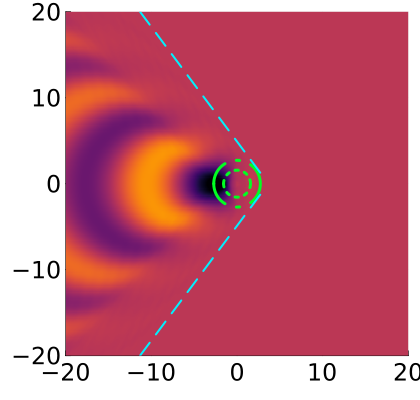

In [72]:
lhs_x = true_xvals[1]
lhs_y = sv125[6][1]
gamma = 1/sqrt(1.25^2-1)
x_line = lhs_x+G[8]:0.01:7pi/8
y_low = zeros(length(x_line))
y_up = zeros(length(x_line))
z_line = zeros(length(x_line))
for i in 1:length(z_line)
    z_line[i] -= 0.6
    y_low[i] = gamma*x_line[i] - 1.8*r
    y_up[i] = -gamma*x_line[i] + 1.8*r
end

pl = heatmap(true_xvals,sv125[8],true_hr,tickfontsize=16,
                size=(420,400),ylims=[-20,20],xlims=[-20,20],clims=(-0.35,0.35),
                colorbar=false)
plot!(pl,circ_x,circ_plus,label=false,color="#00ff22",linestyle=:dashdot,
        linewidth=3)
plot!(pl,circ_x,circ_minus,label=false,color="#00ff22",linestyle=:dashdot,  
        linewidth=3)
plot!(pl,x_line, y_low,legend=false,color="#00f1ff",linewidth=2,
            linestyle=:dash)
plot!(pl,x_line, y_up, legend=false,color="#00f1ff",linewidth=2,
            linestyle=:dash)
plot!(pl,circ_x1,circ_plus1,label=false,color="#00ff22",linestyle=:dot,
        linewidth=3)
plot!(pl,circ_x1,circ_minus1,label=false,color="#00ff22",linestyle=:dot,  
        linewidth=3)
# savefig(pl,"sup_plots/fig9a_h.pdf")

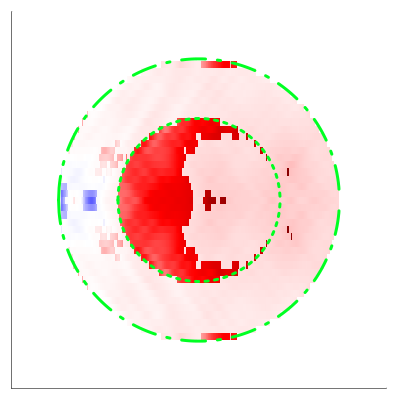

In [13]:
plt_q = heatmap(true_xvals,sv125[8],true_qr,clims=(-0.6,0.6),c=:seismic,
        tickfontsize=16, xticks=false,yticks=false,
        size=(400,400),colorbar=false,
        xlims=[-2*shape_l/3,2*shape_l/3],ylims=[-2*shape_l/3,2*shape_l/3])
plot!(plt_q,circ_x,circ_plus,label=false,color="#00ff22",linestyle=:dashdot,
        linewidth=3)
plot!(plt_q,circ_x,circ_minus,label=false,color="#00ff22",linestyle=:dashdot,  
        linewidth=3)
plot!(plt_q,circ_x1,circ_plus1,label=false,color="#00ff22",linestyle=:dot,
        linewidth=3)
plot!(plt_q,circ_x1,circ_minus1,label=false,color="#00ff22",linestyle=:dot,  
        linewidth=3)
# savefig(plt_q,"sup_plots/fig9a_q.pdf")

In [73]:
sv175 = domain_extend(H[1],H[2],H[16],H[17],H[3],H[4],H[8],H[9],1.75,H[6])

5311


([0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [0.0 0.0 … 2.6473814269505216e-14 2.6419963559001456e-14; 0.0 0.0 … 7.264927608938699e-13 7.110424027403867e-13; … ; 0.0 0.0 … 1.149656373910667e-13 1.3838224899363997e-13; 0.0 0.0 … 0.0 0.0], [0.0 0.0 … -4.461822138421679e-15 -4.526157122134425e-15; 0.0 0.0 … -1.8030481219420054e-12 -1.7950065088201482e-12; … ; 0.0 0.0 … 2.2570843835924985e-13 2.1624668895054793e-13; 0.0 0.0 … 0.0 0.0], [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], Any[0.0, 0.00824, 0.01648, 0.024720000000000002, 0.03296, 0.0412, 0.049440000000000005, 0.05768000000000001, 0.06592, 0.07416  …  43.680240000000005, 43.688480000000006, 43.696720000000006, 43.70496000000001, 43.71320000000001, 43.72144, 43.72968, 43.73792, 43.74616, 43.754400000

In [74]:
# div=200
wid = length(sv175[3][:,1])
x_leng = sqrt(3)pi
# make a matrix to flip the axes
dom_len = Int64(round(1.75*length(sv175[3][1,:])))
true_hr = zeros(wid,dom_len);
true_hi = zeros(wid,dom_len);
true_qr = zeros(wid,dom_len)
true_qi = zeros(wid,dom_len);

n = length(sv175[3][1,:])
for i in 1:length(sv175[3][1,:])
    true_qr[:,i] = sv175[1][:,n-i+1]
    true_qi[:,i] = sv175[2][:,n-i+1]
    true_hr[:,i] = sv175[3][:,n-i+1]
    true_hi[:,i] = sv175[4][:,n-i+1]
end
true_xvals = zeros(dom_len)
end_index = n
for i in 1:dom_len
    true_xvals[i] = -sv175[7][end_index] + (i-1)*H[8] + x_leng/2
end

# for i in 1:sv175[12]
#     true_qr[:,i] = sv175[1][:,sv175[12]-i+1]
#     true_qi[:,i] = sv175[2][:,sv175[12]-i+1]
# end
# q_xvals = zeros(sv175[12])
# for i in 1:sv175[12]
#     q_xvals[i] = -x_leng/2 + (i-1)*sv175[8]
# end

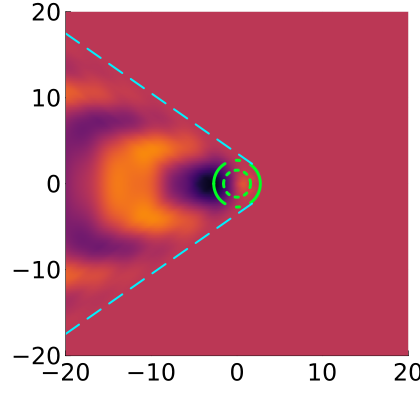

In [75]:
lhs_x = true_xvals[1]
lhs_y = sv175[6][1]
gamma = 1/sqrt(1.75^2-1)
x_line = lhs_x+H[8]:0.01:3pi/4
y_low = zeros(length(x_line))
y_up = zeros(length(x_line))
z_line = zeros(length(x_line))
for i in 1:length(z_line)
    z_line[i] -= 0.6
    y_low[i] = gamma*x_line[i] - 1.3*r
    y_up[i] = -gamma*x_line[i] + 1.3*r
end
pl = heatmap(true_xvals,sv175[8],true_hr,tickfontsize=16,
                size=(420,400),ylims=[-20,20],xlims=[-20,20],clims=(-0.35,0.35),colorbar=false)
plot!(pl,circ_x,circ_plus,label=false,color="#00ff22",linestyle=:dashdot,  
        linewidth=3)
plot!(pl,circ_x,circ_minus,label=false,color="#00ff22",linestyle=:dashdot,  
        linewidth=3)
plot!(pl,circ_x1,circ_plus1,label=false,color="#00ff22",linestyle=:dot,
        linewidth=3)
plot!(pl,circ_x1,circ_minus1,label=false,color="#00ff22",linestyle=:dot,  
        linewidth=3)
plot!(pl,x_line, y_low,legend=false,color="#00f1ff",linewidth=2,
            linestyle=:dash)
plot!(pl,x_line, y_up,legend=false,color="#00f1ff",linewidth=2,
            linestyle=:dash)
# savefig(pl,"sup_plots/fig9b_h.pdf")

In [ ]:
plt_q = heatmap(true_xvals,sv175[8],true_qr,clims=(-0.6,0.6),c=:seismic,
        tickfontsize=16, xticks=false,yticks=false,
        size=(400,400),colorbar=false,
        xlims=[-2*shape_l/3,2*shape_l/3],ylims=[-2*shape_l/3,2*shape_l/3])
plot!(plt_q,circ_x,circ_plus,label=false,color="#00ff22",linestyle=:dashdot,
        linewidth=3)
plot!(plt_q,circ_x,circ_minus,label=false,color="#00ff22",linestyle=:dashdot,  
        linewidth=3)
plot!(plt_q, circ_x1,circ_plus1,label=false,color="#00ff22",linestyle=:dot,
        linewidth=3)
plot!(plt_q, circ_x1,circ_minus1,label=false,color="#00ff22",linestyle=:dot,  
        linewidth=3)
# savefig(plt_q,"sup_plots/fig9b_q.pdf")

"/Users/daire/shape-considerations-in-wdp/newdata/sup_plots/fig9b_q.pdf"

----
#### Data

In [17]:
print("v=1.25",
    "\ncircle thrust = ", E[7],
    "\ncirle power = ", E[13],
    "\ncircle eff = ", E[7]/E[13],
    "\ngen thrust = ", G[7],
    "\ngen power = ", G[13],
    "\ngen eff = ", G[7]/G[13])

v=1.25
circle thrust = 0.06313143247983671
cirle power = 0.17243470723451648
circle eff = 0.3661178975644157
gen thrust = 0.07624156967241949
gen power = 0.15090578850916186
gen eff = 0.5052262767759281

In [18]:
print("v=1.75",
    "\ncircle thrust = ", F[7],
    "\ncirle power = ", F[13],
    "\ncircle eff = ", F[7]/F[13],
    "\ngen thrust = ", H[7],
    "\ngen power = ", H[13],
    "\ngen eff = ", H[7]/H[13])

v=1.75
circle thrust = 0.018172692146687156
cirle power = 0.14241412145251892
circle eff = 0.12760456590497565
gen thrust = 0.044681007221652094
gen power = 0.11292453927816566
gen eff = 0.395671370521069

----
### Making colour bar

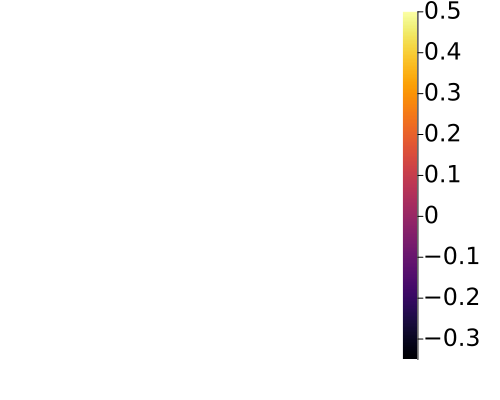

In [156]:
hcbar = heatmap(rand(2,2), framestyle=:none, cbar=true, lims=(-1,0),
            size=(500,400),tickfontsize=16,right_margin=1.25Plots.cm,
            clims=(-0.35,0.5))
# savefig(hcbar,"sup_fig_hbar.pdf")

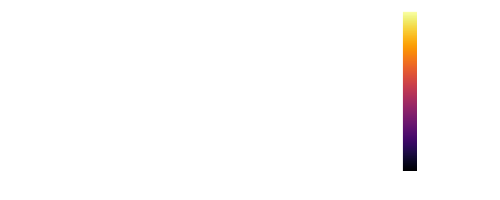

In [157]:
qcbar = heatmap(rand(2,2), framestyle=:none, cbar=true, lims=(-1,0),
            size=(500,200),tickfontsize=16,right_margin=1.25Plots.cm,
            clims=(-0.5,0.5),colorbar_ticks=false)
# savefig(qcbar,"sup_plots/fig_6_qbar.pdf")